# 02 – Modellering, evaluering og lagring av modell

Denne notebooken:
1. Bruker **samme train/test-oppdeling** som notebook 01 (samme `random_state`)
2. Bygger en **pipeline** som erstatter 0-verdier med median og skalerer dataene
3. Sammenligner tre modeller med **5-fold kryssvalidering**: logistisk regresjon, random forest og gradient boosting
4. Tuner hyperparametre og velger den beste modellen
5. Velger en **beslutningsterskel** som gir høy recall
6. Evaluerer på testsettet og sammenligner med baselinene
7. Undersøker **feature importance** og **feilprediksjoner**
8. Lagrer modellen til `model/diabetes_model.joblib`, som nettsiden skal bruke

Kjør alt med **Run All**. Gradient boosting-tuningen kan ta et halvt minutt.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, RocCurveDisplay)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print("scikit-learn versjon:", sklearn.__version__)

scikit-learn versjon: 1.9.1


## 1. Last inn data og del opp (identisk med notebook 01)

In [2]:
df = pd.read_csv("../data/diabetes.csv")
X = df.drop(columns="Outcome")
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Trening:", X_train.shape, " Test:", X_test.shape)

Trening: (614, 8)  Test: (154, 8)


## 2. Forbehandling i en pipeline

- I `Glucose, BloodPressure, SkinThickness, Insulin, BMI` betyr 0 «mangler». `SimpleImputer(missing_values=0)` erstatter dem med **medianen fra treningsdataene**.
- Logistisk regresjon får i tillegg `StandardScaler`. Trebaserte modeller trenger ikke skalering.
- Fordi alt ligger i én pipeline, beregnes medianen på nytt i hver fold i kryssvalideringen (ingen data-lekkasje), og nettsiden bruker nøyaktig samme behandling.
- `class_weight="balanced"` gir de syke større vekt under trening, fordi datasettet er ubalansert.

In [3]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

def make_preprocess():
    return ColumnTransformer(
        [("impute_zeros", SimpleImputer(missing_values=0, strategy="median"), zero_cols)],
        remainder="passthrough",
    )

models = {
    "Logistisk regresjon": Pipeline([
        ("prep", make_preprocess()),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "Random Forest": Pipeline([
        ("prep", make_preprocess()),
        ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", make_preprocess()),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
}

## 3. Sammenligning med 5-fold kryssvalidering (kun treningsdata)

Testsettet røres ikke her. Vi rapporterer gjennomsnitt ± standardavvik over de fem foldene.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    row = {"Modell": name}
    for s in scoring:
        vals = scores[f"test_{s}"]
        row[s] = f"{vals.mean():.3f} ± {vals.std():.3f}"
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).set_index("Modell")
cv_df

,accuracy,precision,recall,f1,roc_auc
Modell,,,,,
Logistisk regresjon,0.762 ± 0.011,0.649 ± 0.026,0.701 ± 0.039,0.672 ± 0.013,0.844 ± 0.016
Random Forest,0.767 ± 0.029,0.663 ± 0.050,0.682 ± 0.020,0.672 ± 0.033,0.822 ± 0.029
Gradient Boosting,0.749 ± 0.017,0.659 ± 0.044,0.593 ± 0.023,0.623 ± 0.010,0.820 ± 0.021


## 4. Tuning av hyperparametre

Vi tuner med **ROC AUC** som mål, fordi den måler hvor godt modellen skiller syke fra friske uavhengig av terskel.
Terskelen velger vi etterpå for å oppnå høy recall.

In [5]:
param_grids = {
    "Logistisk regresjon": {"clf__C": [0.01, 0.1, 1, 10]},
    "Random Forest": {
        "clf__n_estimators": [200, 500],
        "clf__max_depth": [None, 5, 10],
        "clf__min_samples_leaf": [1, 5],
    },
    "Gradient Boosting": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [2, 3],
    },
}

searches = {}
tune_rows = []
for name, model in models.items():
    gs = GridSearchCV(model, param_grids[name], cv=cv, scoring="roc_auc", n_jobs=-1)
    gs.fit(X_train, y_train)
    searches[name] = gs
    tune_rows.append({"Modell": name, "Beste CV ROC AUC": round(gs.best_score_, 3), "Beste parametre": gs.best_params_})

tune_df = pd.DataFrame(tune_rows).set_index("Modell")
tune_df

,Beste CV ROC AUC,Beste parametre
Modell,,
Logistisk regresjon,0.845,{'clf__C': 0.1}
Random Forest,0.838,"{'clf__max_depth': 5, 'clf__min_samples_leaf':..."
Gradient Boosting,0.830,"{'clf__learning_rate': 0.05, 'clf__max_depth':..."


In [6]:
best_name = tune_df["Beste CV ROC AUC"].idxmax()
best_model = searches[best_name].best_estimator_
print("Valgt modell:", best_name)
print("Parametre:", searches[best_name].best_params_)

Valgt modell: Logistisk regresjon
Parametre: {'clf__C': 0.1}


## 5. Valg av beslutningsterskel

Standard er å si «diabetes» når sannsynligheten er ≥ 0,5. For screening vil vi heller fange opp flest mulig syke.
Vi bruker kryssvaliderte sannsynligheter på **treningsdataene** og velger den **høyeste terskelen som gir recall ≥ 0,75**
(høyest mulig terskel gir færrest falske alarmer).

Valgt terskel: 0.47


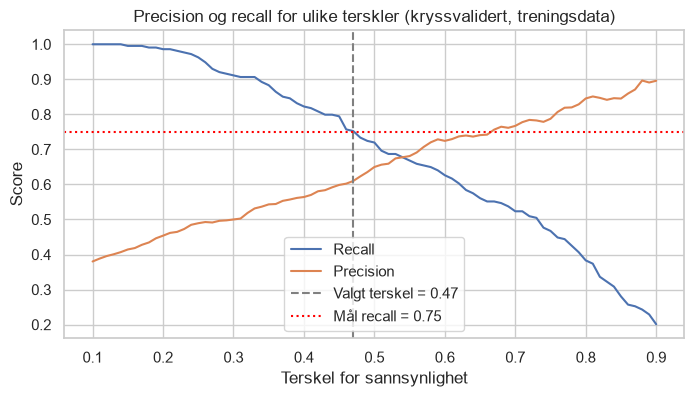

In [7]:
TARGET_RECALL = 0.75

proba_cv = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

ths = np.round(np.arange(0.10, 0.91, 0.01), 2)
rec = [recall_score(y_train, (proba_cv >= t).astype(int)) for t in ths]
pre = [precision_score(y_train, (proba_cv >= t).astype(int), zero_division=0) for t in ths]

ok = [t for t, r in zip(ths, rec) if r >= TARGET_RECALL]
threshold = float(max(ok)) if ok else 0.5
print(f"Valgt terskel: {threshold:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(ths, rec, label="Recall")
plt.plot(ths, pre, label="Precision")
plt.axvline(threshold, color="grey", linestyle="--", label=f"Valgt terskel = {threshold:.2f}")
plt.axhline(TARGET_RECALL, color="red", linestyle=":", label=f"Mål recall = {TARGET_RECALL}")
plt.xlabel("Terskel for sannsynlighet")
plt.ylabel("Score")
plt.title("Precision og recall for ulike terskler (kryssvalidert, treningsdata)")
plt.legend()
plt.show()

## 6. Endelig evaluering på testsettet

Nå bruker vi testsettet for første og eneste gang. Baselinene fra notebook 01 regnes ut på nytt, slik at alt står i samme tabell.

In [8]:
def evaluate(name, y_true, y_pred, y_proba=None):
    return {
        "Modell": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
    }

results = []

# Baseline 1
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
results.append(evaluate("Baseline: alltid 'ikke diabetes'", y_test, dummy.predict(X_test)))

# Baseline 2 (samme metode som notebook 01)
glu_ths = range(80, 200)
best_t = list(glu_ths)[int(np.argmax([f1_score(y_train, (X_train["Glucose"] >= t).astype(int)) for t in glu_ths]))]
results.append(evaluate(f"Baseline: Glucose >= {best_t}", y_test, (X_test["Glucose"] >= best_t).astype(int)))

# Alle tre tunede modeller med standard terskel 0,5
for name, gs in searches.items():
    p = gs.best_estimator_.predict_proba(X_test)[:, 1]
    results.append(evaluate(f"{name} (terskel 0,50)", y_test, (p >= 0.5).astype(int), p))

# Valgt modell med valgt terskel
proba_test = best_model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= threshold).astype(int)
results.append(evaluate(f"{best_name} (terskel {threshold:.2f})", y_test, pred_test, proba_test))

results_df = pd.DataFrame(results).set_index("Modell").round(3)
results_df

,Accuracy,Precision,Recall,F1,ROC AUC
Modell,,,,,
Baseline: alltid 'ikke diabetes',0.649,0.000,0.000,0.000,NaN
Baseline: Glucose >= 125,0.682,0.540,0.630,0.581,NaN
"Logistisk regresjon (terskel 0,50)",0.708,0.571,0.667,0.615,0.810
"Random Forest (terskel 0,50)",0.727,0.588,0.741,0.656,0.811
"Gradient Boosting (terskel 0,50)",0.714,0.614,0.500,0.551,0.811
Logistisk regresjon (terskel 0.47),0.714,0.571,0.741,0.645,0.810


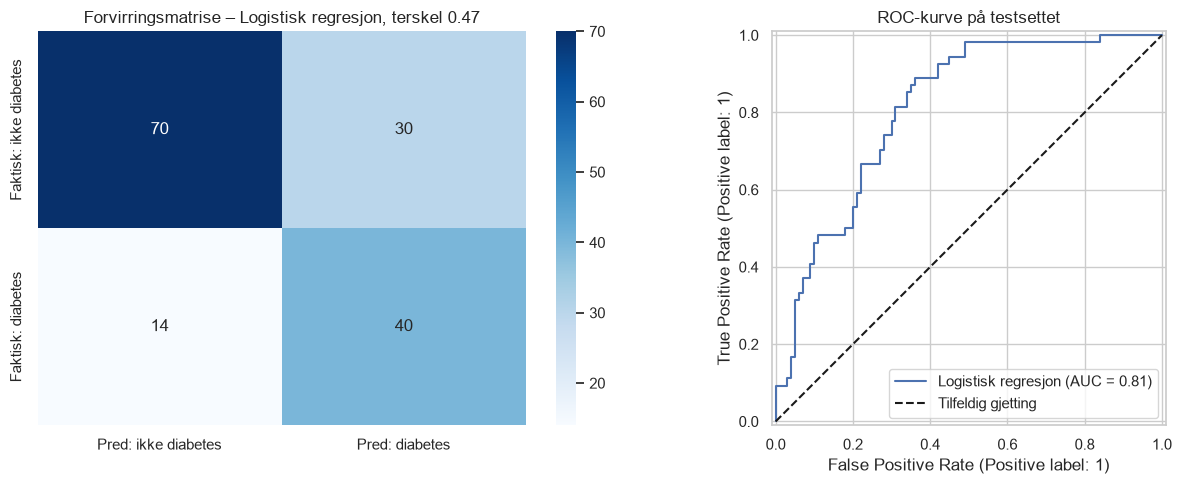

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred: ikke diabetes", "Pred: diabetes"],
            yticklabels=["Faktisk: ikke diabetes", "Faktisk: diabetes"])
axes[0].set_title(f"Forvirringsmatrise – {best_name}, terskel {threshold:.2f}")

RocCurveDisplay.from_predictions(y_test, proba_test, name=best_name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", label="Tilfeldig gjetting")
axes[1].set_title("ROC-kurve på testsettet")
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Feature importance

*Permutation importance*: vi stokker om én feature om gangen og måler hvor mye ROC AUC faller.
Jo større fall, desto viktigere er featuren for modellen.

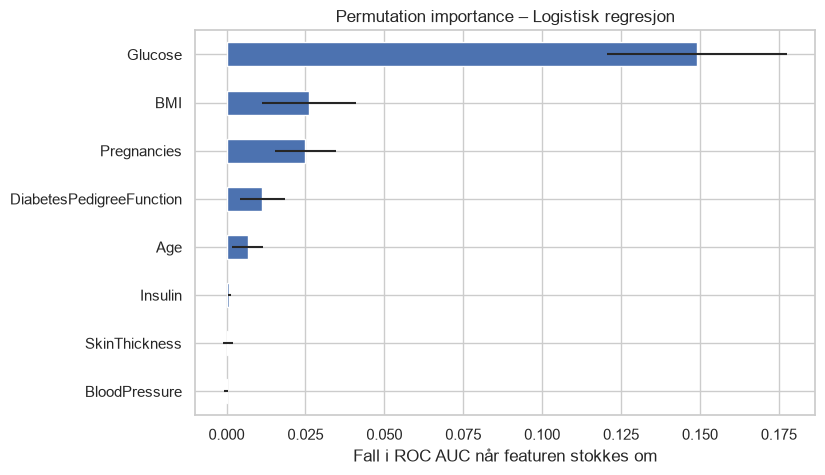

Glucose                     0.149
BMI                         0.026
Pregnancies                 0.025
DiabetesPedigreeFunction    0.011
Age                         0.007
Insulin                     0.001
SkinThickness               0.000
BloodPressure              -0.000
dtype: float64

In [10]:
pi = permutation_importance(best_model, X_test, y_test, scoring="roc_auc",
                            n_repeats=30, random_state=RANDOM_STATE)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values()

imp.plot(kind="barh", xerr=pd.Series(pi.importances_std, index=X_test.columns)[imp.index], figsize=(8, 5))
plt.xlabel("Fall i ROC AUC når featuren stokkes om")
plt.title(f"Permutation importance – {best_name}")
plt.show()

imp.sort_values(ascending=False).round(3)

## 8. Analyse av feilprediksjoner

Hvem overser modellen (falske negative), og hvem gir den falsk alarm for (falske positive)?
Vi sammenligner gjennomsnittsverdiene for hver gruppe.

In [11]:
err = X_test.copy()
err["Faktisk"] = y_test.values
err["Sannsynlighet"] = proba_test.round(2)
err["Predikert"] = pred_test

def kategori(r):
    if r.Faktisk == 1 and r.Predikert == 1: return "Riktig syk (TP)"
    if r.Faktisk == 0 and r.Predikert == 0: return "Riktig frisk (TN)"
    if r.Faktisk == 1: return "Oversett syk (FN)"
    return "Falsk alarm (FP)"

err["Type"] = err.apply(kategori, axis=1)
print(err["Type"].value_counts())

err.groupby("Type")[["Glucose", "BMI", "Age", "Insulin", "DiabetesPedigreeFunction", "Sannsynlighet"]].mean().round(1)

Type
Riktig frisk (TN)    70
Riktig syk (TP)      40
Falsk alarm (FP)     30
Oversett syk (FN)    14
Name: count, dtype: int64


,Glucose,BMI,Age,Insulin,DiabetesPedigreeFunction,Sannsynlighet
Type,,,,,,
Falsk alarm (FP),140.2,36.7,37.1,133.4,0.4,0.7
Oversett syk (FN),113.6,31.4,29.3,21.6,0.4,0.3
Riktig frisk (TN),97.8,27.9,28.1,58.6,0.4,0.2
Riktig syk (TP),149.2,36.1,38.8,114.6,0.6,0.8


In [12]:
# De syke pasientene modellen overså
err[err["Type"] == "Oversett syk (FN)"].sort_values("Sannsynlighet")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Faktisk,Sannsynlighet,Predikert,Type
6,3,78,50,32,88,31.0,0.248,26,1,0.09,0,Oversett syk (FN)
276,7,106,60,24,0,26.5,0.296,29,1,0.22,0,Oversett syk (FN)
124,0,113,76,0,0,33.3,0.278,23,1,0.24,0,Oversett syk (FN)
38,2,90,68,42,0,38.2,0.503,27,1,0.27,0,Oversett syk (FN)
17,7,107,74,0,0,29.6,0.254,31,1,0.29,0,Oversett syk (FN)
419,3,129,64,29,115,26.4,0.219,28,1,0.29,0,Oversett syk (FN)
366,6,124,72,0,0,27.6,0.368,29,1,0.37,0,Oversett syk (FN)
630,7,114,64,0,0,27.4,0.732,34,1,0.39,0,Oversett syk (FN)
678,3,121,52,0,0,36.0,0.127,25,1,0.39,0,Oversett syk (FN)
264,4,123,62,0,0,32.0,0.226,35,1,0.40,0,Oversett syk (FN)


## 9. Lagre modellen

In [13]:
Path("../model").mkdir(exist_ok=True)

bundle = {
    "model": best_model,
    "threshold": threshold,
    "features": list(X.columns),
    "model_name": best_name,
    "sklearn_version": sklearn.__version__,
}
joblib.dump(bundle, "../model/diabetes_model.joblib")
print("Lagret til ../model/diabetes_model.joblib")

# Test at den kan lastes inn igjen og gi en prediksjon
loaded = joblib.load("../model/diabetes_model.joblib")
eksempel = pd.DataFrame([{"Pregnancies": 2, "Glucose": 150, "BloodPressure": 70, "SkinThickness": 30,
                          "Insulin": 0, "BMI": 33.0, "DiabetesPedigreeFunction": 0.5, "Age": 45}])
p = loaded["model"].predict_proba(eksempel)[0, 1]
print(f"Eksempelpasient: sannsynlighet {p:.2f} → {'høy risiko' if p >= loaded['threshold'] else 'lav risiko'}")

Lagret til ../model/diabetes_model.joblib
Eksempelpasient: sannsynlighet 0.69 → høy risiko


## 10. Oppsummering

- Beste modell (kryssvalidert ROC AUC 0,845): Logistisk regresjon med C = 0,1
- Valgt terskel: 0,47 (gir recall ≥ 0,75 i kryssvalidering på treningsdata)
- Testresultat: accuracy 0,714, precision 0,571, recall 0,741, F1 0,645, ROC AUC 0,810
- Sammenlignet med Glucose-regelen: finner 40 av 54 syke (mot 34), overser 14 (mot 20), med 30 falske alarmer (mot 29)
- Viktigste features: Glucose (0,149), deretter BMI (0,026), Pregnancies (0,025), DiabetesPedigreeFunction (0,011), Age (0,007). Insulin, SkinThickness og BloodPressure ≈ 0
- Typisk for oversette pasienter: lavere blodsukker (snitt 114), yngre (snitt 29 år), og 10 av 14 mangler insulinverdi